In [33]:
from typing import TypedDict
from langgraph.graph import StateGraph, START,END

In [34]:
class AgentState(TypedDict):
    number1: int
    operation :str
    number2 :int
    number3:int
    number4: int
    finalNumber:int
    finalNumber2:int


In [35]:
def adder(state:AgentState)->AgentState:
    """This is add method"""

    state['finalNumber'] = state['number1']+ state['number2']
    return state

def substractor(state:AgentState)->AgentState:
    """This is subtractor method"""

    state['finalNumber'] = state['number1'] - state['number2']
    return state
def adder2(state:AgentState)->AgentState:
    """This is add method"""

    state['finalNumber2'] = state['number3']+ state['number4']
    return state

def substractor2(state:AgentState)->AgentState:
    """This is subtractor method"""

    state['finalNumber2'] = state['number3'] - state['number4']
    return state

def decide_next_node(state:AgentState)->AgentState:
    """This node wil selector the next node"""

    if state['operation'] == "+":
        return "add_operation"
    elif state['operation'] == "-":
        return "subtractor_operation"


In [36]:
graph = StateGraph(AgentState)
graph.add_node("add_node",adder)
graph.add_node("subtract_node",substractor)
graph.add_node("add_node2",adder2)
graph.add_node("subtract_node2",substractor2)
graph.add_node("router",lambda state:state)
graph.add_node("router2",lambda state:state)
graph.add_edge(START,"router")
graph.add_conditional_edges("router",decide_next_node,
                            
                            {
                                "add_operation":"add_node",
                                "subtractor_operation":"subtract_node"
                            })
                        
graph.add_edge("add_node","router2")
graph.add_edge("subtract_node","router2")
graph.add_conditional_edges("router2",decide_next_node,
                            
                            {
                                "add_operation":"add_node2",
                                "subtractor_operation":"subtract_node2"
                            })
app =graph.compile()



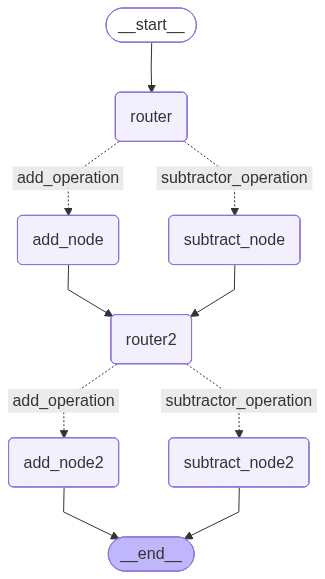

In [37]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [39]:
initstate = AgentState(number1=10,number2=5,operation="-",number3=7,number4=2,operation2="+",finalNumber=0,finalNumber2=0)
print(app.invoke(initstate))

{'number1': 10, 'operation': '-', 'number2': 5, 'number3': 7, 'number4': 2, 'finalNumber': 5, 'finalNumber2': 5}
